<a href="https://colab.research.google.com/github/L-Poca/Data_Pipeline/blob/rafael_cleaning/notebooks/colab/custom_cnn_refactored.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/L-Poca/Data_Pipeline/blob/rafael_cleaning/notebooks/colab/custom_cnn_refactored.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Custom CNN - Version Refactorisée

Ce notebook utilise les fonctions utilitaires de `src.notebooks.notebook_utils` pour un code plus propre et réutilisable.

## 1. Configuration et Imports

In [22]:
"""
╔════════════════════════════════════════════════════════════════════════════╗
║  🎯 CELLULE DE CONFIGURATION STANDALONE - COPIER-COLLER DANS VOS NOTEBOOKS ║
╚════════════════════════════════════════════════════════════════════════════╝

INSTRUCTIONS:
-------------
1. Copiez TOUT le contenu de cette cellule
2. Collez-le comme PREMIÈRE CELLULE de votre notebook
3. Exécutez la cellule
4. Les variables sont prêtes à l'emploi !

Cette cellule est 100% autonome et fonctionne partout :
✅ Google Colab (clone + installe automatiquement)
✅ WSL / Linux Local
✅ Tout environnement Jupyter

APRÈS EXÉCUTION, VOUS POUVEZ UTILISER:
- config: Objet de configuration (config.batch_size, config.data_dir, etc.)
- ENV: Environnement détecté ('colab', 'wsl', 'local')
- Tous les imports des transformers

"""

# =============================================================================
# IMPORTS STANDARDS
# =============================================================================

import os
import sys
import subprocess
from pathlib import Path


# =============================================================================
# DÉTECTION AUTOMATIQUE DE L'ENVIRONNEMENT
# =============================================================================

def detect_environment():
    """Détecte l'environnement (colab, wsl, local)"""
    try:
        import google.colab
        return "colab"
    except ImportError:
        is_wsl = os.path.exists('/proc/version') and 'microsoft' in open('/proc/version').read().lower()
        return "wsl" if is_wsl else "local"

ENV = detect_environment()
print(f"🌍 Environnement: {ENV.upper()}")


# =============================================================================
# BOOTSTRAP COLAB (Clone + Install si nécessaire)
# =============================================================================

if ENV == "colab":
    print("\n🚀 Bootstrap Colab...")

    os.chdir('/content')
    if not os.path.exists('/content/Data_Pipeline'):
        print("📥 Clonage du repository...")
        subprocess.run(['git', 'clone', 'https://github.com/L-Poca/Data_Pipeline.git'], check=True)

    os.chdir('/content/Data_Pipeline')

    # Checkout de la branche rafael_cleaning
    result = subprocess.run(
        ['git', 'checkout', '-b', 'rafael_cleaning', 'origin/rafael_cleaning'],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        # Si la branche locale existe déjà, juste switcher
        subprocess.run(['git', 'checkout', 'rafael_cleaning'], capture_output=True)

    # Installation du package en mode éditable (sans dépendances - détection Colab dans setup.py)
    print("📦 Installation du package...")
    result = subprocess.run(['pip', 'install', '-e', '.', '--quiet'], capture_output=True, text=True)
    if result.returncode != 0:
        print(f"⚠️ Erreur installation: {result.stderr}")
    else:
        print("✅ Package installé")

    print("💾 Montage Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')

    # Extraction dataset
    archive_data = '/content/drive/MyDrive/DS_COVID/archive_covid.zip'
    if os.path.exists(archive_data):
        print("📦 Extraction dataset...")
        os.makedirs('./data/raw/', exist_ok=True)
        subprocess.run(['unzip', '-o', '-q', archive_data, '-d', './data/raw/COVID-19_Radiography_Dataset/'])

    # Extraction models

    archive_models = '/content/drive/MyDrive/DS_COVID/inceptionv3_best.zip'
    if os.path.exists(archive_models):
        print("📦 Extraction models...")
        os.makedirs('./models/', exist_ok=True)
        subprocess.run(['unzip', '-o', '-q', archive_models, '-d', './models/'])



    print("✅ Bootstrap terminé")


# =============================================================================
# CONFIGURATION DES CHEMINS
# =============================================================================

# Déterminer project_root selon l'environnement
if ENV == "colab":
    project_root = Path('/content/Data_Pipeline')
elif ENV == "wsl":
    project_root = Path('/home/cepa/DST/projet_DS/Data_Pipeline/Data_Pipeline')
else:  # local
    # Depuis un notebook dans src/notebooks/
    project_root = Path.cwd().parent.parent

# Ajouter src/ au sys.path pour les imports
# src_path = str(project_root / 'src')
# if src_path not in sys.path:
#     sys.path.insert(0, src_path)
#     print(f"✅ Chemin src/ ajouté: {src_path}")

# Charger la configuration depuis JSON
from src.utils.config import build_config

config = build_config(project_root, ENV)

# Exports pour compatibilité avec anciens notebooks
data_dir = config.data_dir
categories = config.classes
img_size = config.img_size


# =============================================================================
# IMPORTS DES TRANSFORMERS
# =============================================================================

try:
    from src.features.Pipelines.Transformateurs.image_loaders import ImageLoader
    from src.features.Pipelines.Transformateurs.image_preprocessing import (
        ImageResizer, ImageNormalizer, ImageFlattener, ImageMasker
    )
    from src.features.Pipelines.Transformateurs.image_augmentation import (
        ImageAugmenter, ImageRandomCropper
    )
    from src.features.Pipelines.Transformateurs.image_features import (
        ImageHistogram, ImagePCA, ImageStandardScaler
    )
    print("✅ Transformers importés")
except ImportError as e:
    print(f"⚠️ Erreur import transformers: {e}")


# =============================================================================
# IMPORTS ML/DL
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# =============================================================================
# CONFIGURATION MATPLOTLIB
# =============================================================================

plt.rcParams['figure.figsize'] = (15, 10)
sns.set_style('whitegrid')

# =============================================================================
# AFFICHAGE DU RÉSUMÉ
# =============================================================================

print("\n" + "=" * 70)
print("✅ CONFIGURATION PRÊTE - Data Pipeline")
print("=" * 70)
print(f"📂 Projet: {project_root}")
print(f"📊 Dataset: {data_dir}")
print(f"🏷️ Classes: {', '.join(categories)}")
print(f"🎛️ Images: {img_size}")
print(f"🔧 Batch: {config.batch_size} | Époques: {config.epochs}")
print(f"📐 Dataset accessible: {'✅' if data_dir.exists() else '❌'}")
print("=" * 70)
print("\n💡 Variables disponibles:")
print("   • config: Configuration complète (Config object)")
print("   • ENV: Environnement actuel")
print("\n🎯 Transformers disponibles:")
print("   • ImageLoader, ImageResizer, ImageNormalizer, ImageFlattener")
print("   • ImageAugmenter, ImageRandomCropper")
print("   • ImageHistogram, ImagePCA, ImageStandardScaler")
print("=" * 70)
# Fin de la cellule de configuration standalone

🌍 Environnement: COLAB

🚀 Bootstrap Colab...
📦 Installation du package...
✅ Package installé
💾 Montage Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Extraction dataset...
📦 Extraction models...
✅ Bootstrap terminé
✅ Configuration Colab chargée et mergée
✅ Transformers importés

✅ CONFIGURATION PRÊTE - Data Pipeline
📂 Projet: /content/Data_Pipeline
📊 Dataset: /content/Data_Pipeline/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
🏷️ Classes: COVID, Normal, Lung_Opacity, Viral Pneumonia
🎛️ Images: (256, 256)
🔧 Batch: 64 | Époques: 100
📐 Dataset accessible: ✅

💡 Variables disponibles:
   • config: Configuration complète (Config object)
   • ENV: Environnement actuel

🎯 Transformers disponibles:
   • ImageLoader, ImageResizer, ImageNormalizer, ImageFlattener
   • ImageAugmenter, ImageRandomCropper
   • ImageHistogram, ImagePCA, ImageStandardScaler


In [ ]:
# Imports des fonctions utilitaires
from src.notebooks import (
    load_dataset,
    create_preprocessing_pipeline,
    prepare_train_val_test_split,
    compute_class_weights,
    create_data_generators,
    build_custom_cnn,
    compile_model,
    create_callbacks,
    train_model,
    evaluate_model,
    plot_training_curves,
    plot_confusion_matrix,
    select_sample_images,
    run_gradcam_analysis,
)

print("✅ Fonctions utilitaires importées")

# Définition des paramètres principaux

VERBOSE = True
LOAD_MASKS = False # True pour version maskée
N_IMAGES_PER_CLASS = None # None = Charger toutes les images
AUGMENT_TRAIN = True # True pour augmenter les données d'entraînement
BATCH_SIZE = 512
EPOCHS = 3
RANDOM_SEED = 42

✅ Fonctions utilitaires importées


## 2. Chargement et Préparation des Données

In [24]:
# Charger le dataset
image_paths, mask_paths, labels, labels_int = load_dataset(
    data_dir=config.data_dir,
    categories=config.classes,
    n_images_per_class=N_IMAGES_PER_CLASS, # None =  Charger toutes les images
    load_masks=LOAD_MASKS,  # True pour version maskée
    verbose=VERBOSE
)

CHARGEMENT DES DONNÉES
  COVID               : 3616 images
  Normal              : 10192 images
  Lung_Opacity        : 6012 images
  Viral Pneumonia     : 1345 images

  Total: 21165 images
  Classes: 4
  Distribution: [ 3616 10192  6012  1345]


In [25]:
# Créer la pipeline de preprocessing
pipeline = create_preprocessing_pipeline(
    img_size=(128, 128),
    color_mode='RGB',
    mask_paths=None,  # mask_paths pour version maskée
    verbose=VERBOSE
)

# Charger et préprocesser les images
print("\nChargement des images...")
images = pipeline.fit_transform(image_paths)
images = images.astype('float32') / 255.0

print(f"\n📊 Images préparées:")
print(f"  Shape: {images.shape}")
print(f"  Range: [{images.min():.3f}, {images.max():.3f}]")
print(f"  Dtype: {images.dtype}")

PREPROCESSING PIPELINE

✅ Pipeline créée avec 2 étapes

Chargement des images...


Resizing images: 100%|██████████| 21165/21165 [00:35<00:00, 598.60it/s]



📊 Images préparées:
  Shape: (21165, 128, 128, 3)
  Range: [0.000, 1.000]
  Dtype: float32


In [26]:
# Split train/val/test
X_train, X_val, X_test, y_train_cat, y_val_cat, y_test_cat = prepare_train_val_test_split(
    images=images,
    labels_int=labels_int,
    num_classes=len(config.classes),
    test_size=0.15,
    val_size=0.15,
    random_seed=RANDOM_SEED,
    verbose=VERBOSE
)

# Récupérer les labels integer pour le calcul des class weights
y_train = np.argmax(y_train_cat, axis=1)
y_val = np.argmax(y_val_cat, axis=1)
y_test = np.argmax(y_test_cat, axis=1)

TRAIN/VALIDATION/TEST SPLIT

Train set: 14815 images
  Distribution: [2532 7134 4208  941]

Validation set: 3175 images
  Distribution: [ 542 1529  902  202]

Test set: 3175 images
  Distribution: [ 542 1529  902  202]


In [27]:
# Calculer les class weights
class_weights = compute_class_weights(
    y_train=y_train,
    categories=config.classes,
    verbose=VERBOSE
)

CLASS WEIGHTING

Poids de classe:
  COVID               : 1.463
  Normal              : 0.519
  Lung_Opacity        : 0.880
  Viral Pneumonia     : 3.936

✅ Class weighting activé pour un apprentissage équilibré


In [ ]:
# Créer les data generators

train_generator, val_generator, test_generator = create_data_generators(
    X_train=X_train,
    y_train_cat=y_train_cat,
    X_val=X_val,
    y_val_cat=y_val_cat,
    X_test=X_test,
    y_test_cat=y_test_cat,
    batch_size=BATCH_SIZE,
    augment_train=AUGMENT_TRAIN,
    verbose=VERBOSE
)

DATA AUGMENTATION

✅ Data augmentation configurée:
  • Rotation: ±10°
  • Shift: ±10%
  • Zoom: ±10%
  • Horizontal flip

📊 Création des générateurs...
  Train: 29 batches de 512
  Val:   7 batches de 512
  Test:  7 batches de 512


## 3. Construction et Compilation du Modèle

In [29]:
# Construire le modèle
model = build_custom_cnn(
    input_shape=(128, 128, 3),
    num_classes=len(config.classes),
    verbose=VERBOSE
)

# Afficher le résumé
model.summary()

CUSTOM CNN ARCHITECTURE


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



✅ Modèle créé
   Nom: CustomCNN_COVID19
   Input shape: (128, 128, 3)
   Output classes: 4


Model: "CustomCNN_COVID19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,050,404 (34.52 MB)

 Trainable params: 9,044,900 (34.50 MB)

 Non-trainable params: 5,504 (21.50 KB)

In [30]:
# Compiler le modèle
model = compile_model(
    model=model,
    learning_rate=0.001,
    verbose=VERBOSE
)

COMPILATION DU MODÈLE

✅ Modèle compilé
   Optimizer: Adam
   Learning rate: 0.001
   Loss: CategoricalCrossentropy
   Metrics: accuracy, auc, precision, recall


In [31]:
# Créer les callbacks
callbacks = create_callbacks(
    models_dir=config.results_dir / 'custom_cnn_models',
    monitor='val_accuracy',
    patience_early_stop=15,
    patience_reduce_lr=5,
    verbose=VERBOSE)

CALLBACKS

✅ Callbacks configurés:
   • EarlyStopping (patience=15)
   • ReduceLROnPlateau (factor=0.5, patience=5)
   • ModelCheckpoint (monitor=val_accuracy)


## 4. Entraînement

In [32]:
# Entraîner le modèle


history = train_model(
    model=model,
    train_generator=train_generator,
    val_generator=val_generator,
    class_weights=class_weights,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=VERBOSE
)

ENTRAÎNEMENT DU MODÈLE

Début de l'entraînement: 3 époques
Class weights activé: ✅




/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3935 - auc: 0.6466 - loss: 3.0371 - precision: 0.4114 - recall: 0.3386
Epoch 1: val_accuracy improved from -inf to 0.17039, saving model to /content/Data_Pipeline/results/custom_cnn_models/best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.3963 - auc: 0.6492 - loss: 3.0281 - precision: 0.4145 - recall: 0.3415 - val_accuracy: 0.1704 - val_auc: 0.3090 - val_loss: 6.5222 - val_precision: 0.1706 - val_recall: 0.1691 - learning_rate: 0.0010
Epoch 2/3
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6093 - auc: 0.8316 - loss: 2.3454 - precision: 0.6425 - recall: 0.5567
Epoch 2: val_accuracy did not improve from 0.17039
29/29 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.6098 - auc: 0.8319 - loss: 2.3440 - precision: 0.6430 - recall: 0.5572 - val_accuracy: 0.0636 - val_auc: 0.2768 - val_loss: 7.7758 - val_precision: 0.0636 - val_recall: 0.0636 - learning_rate: 0.0010
Epoch 3/3
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s

## 5. Visualisation des Courbes d'Apprentissage

VISUALISATION DES COURBES D'APPRENTISSAGE

✅ Graphique sauvegardé: /content/Data_Pipeline/results/custom_cnn_plots/training_curves.png


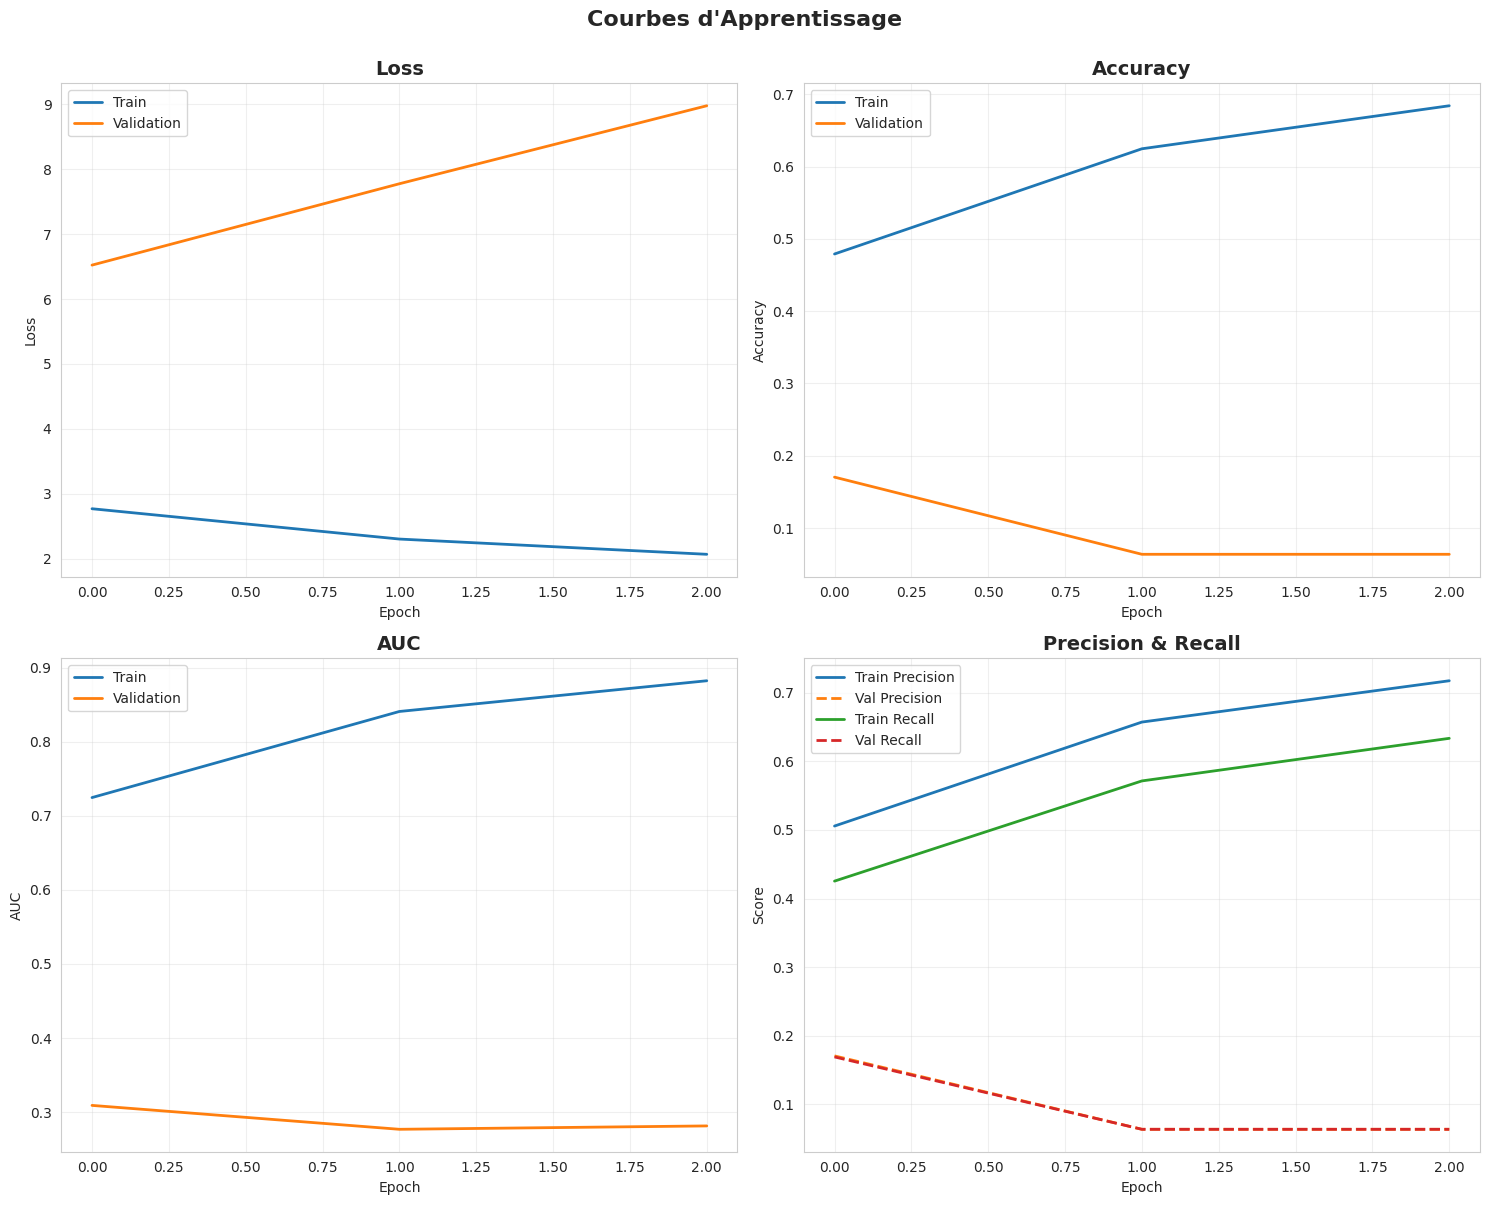

In [33]:
# Plot training curves
plots_dir = config.results_dir / 'custom_cnn_plots'
plots_dir.mkdir(parents=True, exist_ok=True)

fig = plot_training_curves(
    history=history,
    save_path=plots_dir / 'training_curves.png',
    figsize=(15, 12)
)
plt.show()

## 6. Évaluation

In [34]:
# Évaluer le modèle
y_pred, y_pred_proba = evaluate_model(
    model=model,
    X_test=X_test,
    y_test_cat=y_test_cat,
    y_test=y_test,
    categories=config.classes,
    verbose=VERBOSE
)

ÉVALUATION SUR LE TEST SET

Évaluation en cours...

📊 Résultats sur le test set:
   Loss:      6.5236
   Accuracy:  0.1704 (17.04%)
   AUC:       0.3087
   Precision: 0.1696
   Recall:    0.1676
   F1-Score:  0.1686

RAPPORT DE CLASSIFICATION

                 precision    recall  f1-score   support

          COVID     0.1701    0.9945    0.2906       542
         Normal     0.0000    0.0000    0.0000      1529
   Lung_Opacity     0.0000    0.0000    0.0000       902
Viral Pneumonia     0.2857    0.0099    0.0191       202

       accuracy                         0.1704      3175
      macro avg     0.1140    0.2511    0.0774      3175
   weighted avg     0.0472    0.1704    0.0508      3175



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Matrice de confusion sauvegardée: /content/Data_Pipeline/results/custom_cnn_plots/confusion_matrix.png


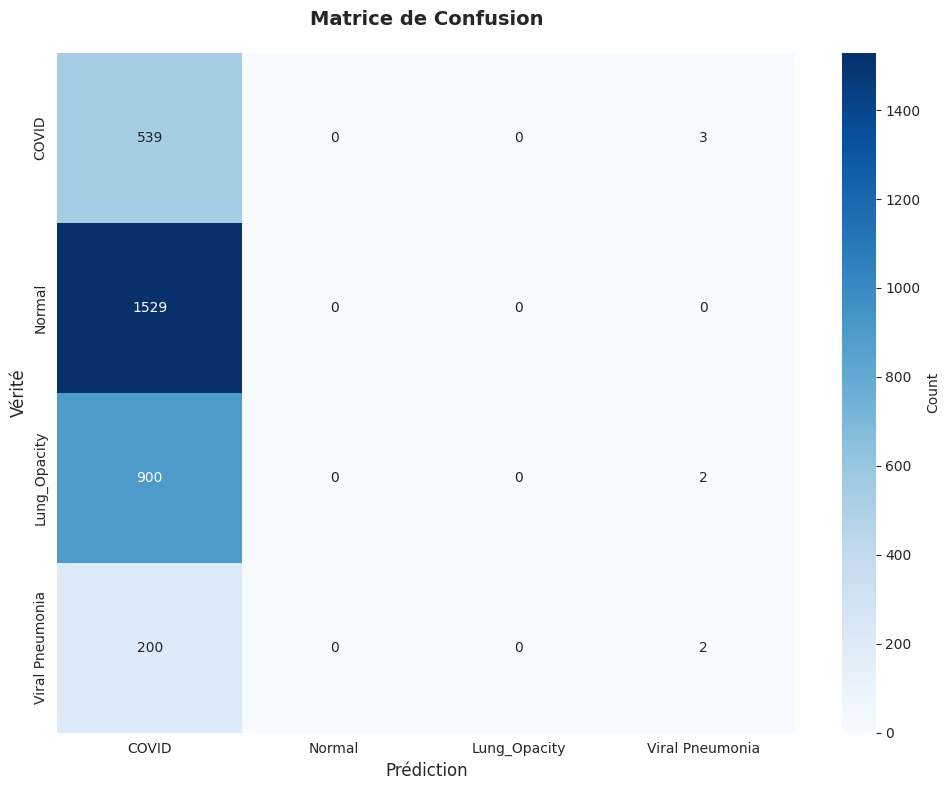

In [35]:
# Matrice de confusion
fig = plot_confusion_matrix(
    y_test=y_test,
    y_pred=y_pred,
    categories=config.classes,
    save_path=plots_dir / 'confusion_matrix.png',
    figsize=(10, 8)
)
plt.show()

## 7. Interprétabilité - Grad-CAM

In [36]:
# Sélectionner des images échantillons
sample_indices = select_sample_images(
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    y_pred_proba=y_pred_proba,
    categories=config.classes,
    n_samples=6,
    random_seed=42,
    verbose=VERBOSE
)


🎯 Analyse de 6 images du test set:
  ✅ Image 2270: Vrai=COVID           | Prédit=COVID           (57.26%)
  ❌ Image 442: Vrai=Normal          | Prédit=COVID           (59.45%)
  ❌ Image 2885: Vrai=Lung_Opacity    | Prédit=COVID           (56.86%)
  ✅ Image 1655: Vrai=COVID           | Prédit=COVID           (55.31%)
  ❌ Image 1001: Vrai=Normal          | Prédit=COVID           (53.62%)
  ❌ Image 2563: Vrai=Lung_Opacity    | Prédit=COVID           (55.06%)


In [37]:
# Analyse Grad-CAM
interp_dir = config.results_dir / 'interpretability_custom_cnn'
interp_dir.mkdir(parents=True, exist_ok=True)

gradcam, heatmaps = run_gradcam_analysis(
    model=model,
    X_test=X_test,
    y_pred=y_pred,
    y_pred_proba=y_pred_proba,
    categories=config.classes,
    sample_indices=sample_indices,
    save_dir=interp_dir,
    verbose=VERBOSE
)

plt.show()

GRAD-CAM - VISUALISATION DES ZONES D'ATTENTION

📐 Couches convolutionnelles disponibles: 10
   Couche utilisée: conv2d_29

🔍 Génération des heatmaps Grad-CAM...


✅ Sauvegardé: /content/Data_Pipeline/results/interpretability_custom_cnn/gradcam_grid.png
✅ Visualisations Grad-CAM générées


## 8. Résumé

✅ Notebook refactorisé utilisant les fonctions utilitaires !

**Avantages:**
- Code plus court et lisible
- Fonctions réutilisables entre notebooks
- Facile à maintenir et débugger
- Paramètres centralisés

In [38]:
print("=" * 70)
print("🎉 NOTEBOOK TERMINÉ")
print("=" * 70)
print("\n✅ Modèle entraîné et évalué")
print("✅ Visualisations générées")
print("✅ Interprétabilité analysée")

🎉 NOTEBOOK TERMINÉ

✅ Modèle entraîné et évalué
✅ Visualisations générées
✅ Interprétabilité analysée
